Siamo molto bravi a programmare


In [3]:
import math
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sys

from mlxtend import __version__ as mlxtend_version
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

from collections import defaultdict
from scipy.stats import pearsonr

DATASET_FOLDER = "dataset/"

Poi abbiamo importato

In [4]:
artists = pd.read_csv(DATASET_FOLDER + 'artists.csv', sep=';')
tracks = pd.read_csv(DATASET_FOLDER + 'tracks.csv', sep=',')

artists_p = artists.add_prefix("artist_")
tracks_p = tracks.add_prefix("track_")

merged = tracks_p.merge(
    artists_p,
    how="left",
    left_on="track_id_artist",
    right_on="artist_id_author"
)

track_cols = [c for c in merged.columns if c.startswith("track_")]
artist_cols = [c for c in merged.columns if c.startswith("artist_")]

merged = merged.drop_duplicates(subset=['track_id'], keep='first')

merged["artist_active_start_year"] = (pd.to_numeric(merged["artist_active_start"].astype(str).str.slice(0, 4), errors="coerce").astype("Int64"))
track_year_num = pd.to_numeric(merged["track_year"], errors="coerce")
active_start_year_num = pd.to_numeric(merged["artist_active_start_year"], errors="coerce")
mask = (track_year_num > active_start_year_num) & (track_year_num < 2027)
merged["track_year"] = track_year_num.where(mask, pd.NA)
merged["track_tot_swear_words"] = merged["track_swear_IT"] + merged["track_swear_EN"]

merged["track_presumed_flatness"] = pd.to_numeric(merged["track_spectral_complexity"], errors="coerce") / (
    pd.to_numeric(merged["track_rolloff"], errors="coerce") - pd.to_numeric(merged["track_centroid"], errors="coerce")
)

merged["track_avg_swear_words"] = merged["track_tot_swear_words"] / merged["track_n_tokens"]


merged["artist_birth_year"] = (
    pd.to_numeric(merged["artist_birth_date"].astype(str).str.slice(0, 4), errors="coerce")
    .astype("Int64")
)

merged["track_artist_age"]= merged["track_year"] - merged["artist_birth_year"]

merged["track_tokens_per_sec"] = merged["track_n_tokens"] / (merged["track_duration_ms"] / 1000)

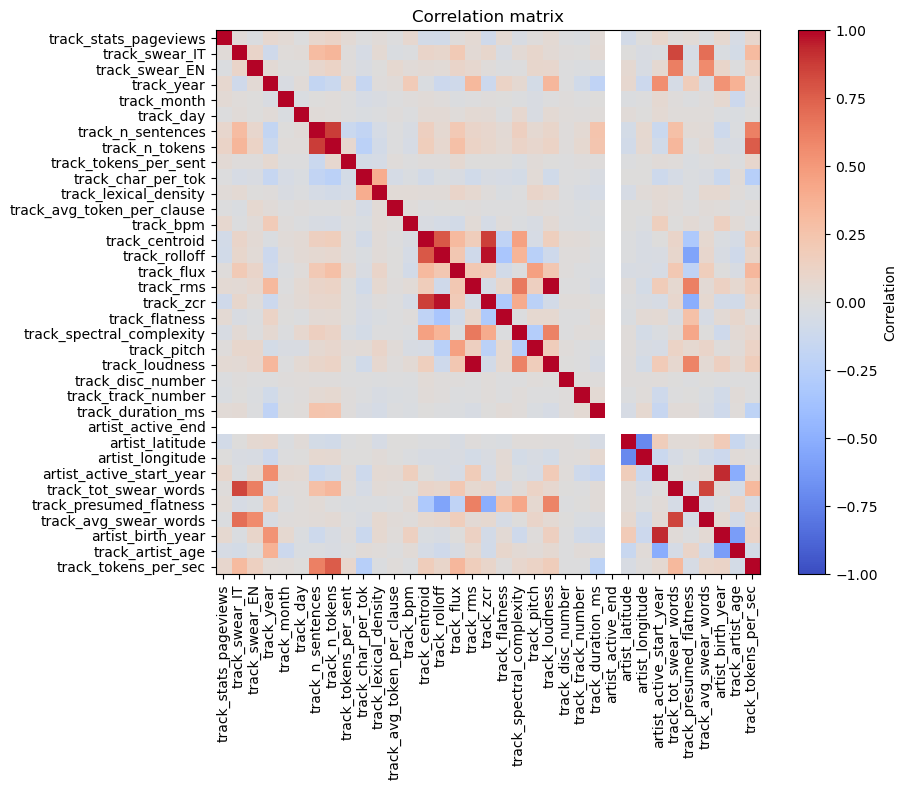

Strongly correlated pairs:
track_rms                  track_loudness               0.995550
track_rolloff              track_zcr                    0.969144
artist_active_start_year   artist_birth_year            0.927034
track_n_sentences          track_n_tokens               0.867862
track_centroid             track_zcr                    0.864460
track_tot_swear_words      track_avg_swear_words        0.850638
track_swear_IT             track_tot_swear_words        0.841941
track_centroid             track_rolloff                0.775799
track_n_tokens             track_tokens_per_sec         0.760865
track_swear_IT             track_avg_swear_words        0.692821
track_rms                  track_spectral_complexity    0.643962
track_swear_EN             track_tot_swear_words        0.624154
track_rms                  track_presumed_flatness      0.616247
track_n_sentences          track_tokens_per_sec         0.610060
track_spectral_complexity  track_loudness               0.60852

In [5]:
# Correlation heatmap for numeric columns
corr = merged.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = corr_pairs.stack().sort_values(ascending=False)
print("Strongly correlated pairs:")
print(strong_pairs[strong_pairs.abs() > 0.5])

Tra rms e loudness teniamo loudness 
tra rolloff, zcr, e centroid teniamo centroid
tra n_sentences e n_token teniamo n_tokens
tra latitude e longitude teniamo latitude
tra swear words IT ed ENG teniamo IT

In [6]:
# Discretize numeric variables into categorical bins
bpm = pd.to_numeric(merged["track_bpm"], errors="coerce")
pop = pd.to_numeric(merged["track_popularity"], errors="coerce")
dur = pd.to_numeric(merged["track_duration_ms"], errors="coerce")
swear_it = pd.to_numeric(merged["track_swear_IT"], errors="coerce")
swear_en = pd.to_numeric(merged["track_swear_EN"], errors="coerce")
swear_total = swear_it.add(swear_en, fill_value=0)

# Swear density = swear words per minute
duration_min = dur / 60000
swear_density = swear_total / duration_min
swear_density = swear_density.replace([np.inf, -np.inf], np.nan)

encoded = pd.get_dummies([])

encoded["bpm"] = pd.cut(
    bpm,
    bins=[-np.inf, 90, 120, np.inf],
    labels=["Slow", "Medium", "Fast"]
 )

encoded["popularity"] = pd.cut(
    pop,
    bins=[-np.inf, 3e1, np.inf],
    labels=["Low", "High"]
 )

encoded["duration"] = pd.cut(
    dur,
    bins=[-np.inf, 180000, 300000, np.inf],
    labels=["Short", "Medium", "Long"]
 )

median_swear_density = swear_density.median(skipna=True)
encoded["swear_density"] = pd.cut(
    swear_density,
    bins=[-np.inf, median_swear_density, np.inf],
    labels=["Low", "High"]
 )

encoded["lexical_density"] = pd.cut(
    pd.to_numeric(merged["track_lexical_density"], errors="coerce"),
    bins=[-np.inf, 0.5, np.inf],
    labels=["Low", "High"]
 )

 
encoded["loudness"] = pd.cut(
    pd.to_numeric(merged["track_loudness"], errors="coerce"),
    bins=[-np.inf, 27, 54, np.inf],
    labels=["Soft", "Medium", "Loud"]
 )

encoded["acuteness"] = pd.cut(
    pd.to_numeric(merged["track_centroid"], errors="coerce"),
    bins=[-np.inf, 0.15, np.inf],
    labels=["Low", "High"]
 )


C:\Users\ludol\AppData\Local\Temp\ipykernel_11220\120024897.py:14: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  encoded = pd.get_dummies([])


In [7]:
# Build transactions with explicit col_name_value labels
transactions = encoded.apply(lambda row: [f"{col}_{row[col]}" for col in encoded.columns], axis=1).tolist()
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

df["swear_high_short"] = df["swear_density_High"] & df["duration_Short"]
df["swear_low_soft"] = df["swear_density_Low"] & df["loudness_Soft"]
df["swear_low_popular"] = df["swear_density_Low"] & df["popularity_High"]
df["lexical_low_soft"] = df["lexical_density_Low"] & df["loudness_Soft"]



In [ ]:
ds= pd.get_dummies([])
ds['track_n_tokens']


Index(['track_id_artist', 'track_name_artist', 'track_full_title',
       'track_title', 'track_featured_artists', 'track_primary_artist',
       'track_language', 'track_album', 'track_stats_pageviews',
       'track_swear_IT', 'track_swear_EN', 'track_swear_IT_words',
       'track_swear_EN_words', 'track_year', 'track_month', 'track_day',
       'track_n_sentences', 'track_n_tokens', 'track_tokens_per_sent',
       'track_char_per_tok', 'track_lexical_density',
       'track_avg_token_per_clause', 'track_bpm', 'track_centroid',
       'track_rolloff', 'track_flux', 'track_rms', 'track_zcr',
       'track_flatness', 'track_spectral_complexity', 'track_pitch',
       'track_loudness', 'track_album_name', 'track_album_release_date',
       'track_album_type', 'track_disc_number', 'track_track_number',
       'track_duration_ms', 'track_explicit', 'track_popularity',
       'track_album_image', 'track_id_album', 'track_lyrics',
       'track_modified_popularity', 'artist_id_author', 'ar